In [18]:
!pip install -q dandi remfile pynwb h5py scikit-learn caveclient pandas matplotlib
import numpy as np
import pandas as pd
import warnings
from dandi.dandiapi import DandiAPIClient
import remfile
import h5py
from pynwb import NWBHDF5IO
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score

warnings.filterwarnings('ignore')

from google.colab import drive
drive.mount('/content/drive')

# --- CONFIGURATION ---
SESSION = 4
SCAN = 7
NWB_PATH = 'sub-17797/sub-17797_ses-4-scan-7_behavior+image+ophys.nwb'
METADATA_PATH = '/content/drive/MyDrive/microns activity data/metadata.pkl'

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
def load_and_align_data(nwb_path, metadata_path, session, scan):
    """Loads NWB fluorescence, extracts timestamps, and aligns to metadata."""
    client = DandiAPIClient()
    dandiset = client.get_dandiset("000402", "draft")
    asset = next(a for a in dandiset.get_assets() if a.path == nwb_path)
    s3_url = asset.get_content_url(follow_redirects=1, strip_query=True)
    io = NWBHDF5IO(file=h5py.File(remfile.File(s3_url), "r"))
    nwb = io.read()

    meta = pd.read_pickle(metadata_path)

    # Filter metadata to this session/scan and get the unique unit_ids
    merged = meta[(meta['session'] == session) & (meta['scan_idx'] == scan)].copy()
    merged = merged.drop_duplicates(subset='unit_id')
    merged['depth_bin'] = merged['um_z'].astype(float).fillna(0).astype(int)

    # Extract the IDs of the "good" neurons directly from the metadata
    unit_ids = merged['unit_id'].values

    ophys_module = nwb.processing['ophys']
    fluorescence_container = ophys_module.data_interfaces['Fluorescence'].roi_response_series

    all_fields = []
    for i in range(1, 9):
        series = fluorescence_container[f'RoiResponseSeries{i}']
        all_fields.append(series.data[:])

    combined_fluorescence = np.concatenate(all_fields, axis=1)

    # We can grab the timestamps directly from the first field (they are all synced)
    frame_times = fluorescence_container['RoiResponseSeries1'].timestamps[:]

    # Align NWB columns to the metadata unit_ids (subtract 1 for 0-based indexing)
    aligned_fluorescence = combined_fluorescence[:, unit_ids - 1].T

    trials = nwb.intervals['Clip'].to_dataframe()
    trials = trials[trials['short_movie_name'].isin(['sports1m', 'Cinematic', 'Rendered'])]

    print(f"Final aligned activity shape: {aligned_fluorescence.shape}")
    return aligned_fluorescence, frame_times, trials, merged

# Run the function
activity, frame_times, trials, merged = load_and_align_data(NWB_PATH, METADATA_PATH, SESSION, SCAN)

Final aligned activity shape: (7493, 40000)


In [4]:
def extract_features(activity_matrix, frame_times, trials, window_seconds=None, method='mean'):
    """Epochs continuous activity into a trial x neuron matrix."""
    X_raw, y_labels = [], []

    for _, trial in trials.iterrows():
        onset = trial.start_time
        window_end = onset + window_seconds if window_seconds else trial.stop_time

        mask = (frame_times >= onset) & (frame_times < window_end)

        if method == 'mean':
            features = activity_matrix[:, mask].mean(axis=1)
        elif method == 'sum':
            features = activity_matrix[:, mask].sum(axis=1)

        X_raw.append(features)
        y_labels.append(trial.short_movie_name)

    return np.array(X_raw), np.array(y_labels)

In [24]:
def run_ensemble_decoder_with_cm(X_subset, y, n_neurons, n_bootstraps=10):
    """
    Returns accuracy, std, chance accuracy, AND an averaged confusion matrix
    (normalized by row so each cell = fraction of true-class trials).
    """
    clf_lr  = LogisticRegression(max_iter=1000, class_weight='balanced', C=1.0)
    clf_svc = SVC(kernel='linear', class_weight='balanced', probability=True, C=1.0)
    clf_rf  = RandomForestClassifier(n_estimators=100, class_weight='balanced', max_depth=5)
    ensemble = VotingClassifier(
        estimators=[('lr', clf_lr), ('svm', clf_svc), ('rf', clf_rf)], voting='soft'
    )
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    accs, shuf_accs = [], []
    cms = []

    for b in range(n_bootstraps):
        rng = np.random.RandomState(b)
        idx    = rng.choice(X_subset.shape[1], n_neurons, replace=False)
        X_boot = StandardScaler().fit_transform(X_subset[:, idx])

        # True accuracy
        accs.append(np.mean(cross_val_score(ensemble, X_boot, y, cv=cv, scoring='accuracy')))

        # Confusion matrix via cross_val_predict (same CV splits)
        y_pred = cross_val_predict(ensemble, X_boot, y, cv=cv)
        cm = confusion_matrix(y, y_pred, labels=classes, normalize='true')
        cms.append(cm)

        # Chance
        y_shuf = rng.permutation(y)
        shuf_accs.append(np.mean(cross_val_score(ensemble, X_boot, y_shuf, cv=cv, scoring='accuracy')))

    mean_cm = np.mean(cms, axis=0)   # average normalized CM across bootstraps
    return np.mean(accs), np.std(accs), np.mean(shuf_accs), mean_cm

In [25]:
def plot_confusion_matrix(cm, title, classes, ax):
    """Plots a single normalized confusion matrix on a given axes."""
    sns.heatmap(
        cm, annot=True, fmt='.2f', cmap='Blues',
        xticklabels=classes, yticklabels=classes,
        vmin=0, vmax=1, ax=ax, linewidths=0.5, linecolor='gray',
        cbar_kws={'shrink': 0.8}
    )
    ax.set_xlabel('Predicted', fontsize=9)
    ax.set_ylabel('True', fontsize=9)
    ax.set_title(title, fontsize=9, fontweight='bold', pad=4)
    ax.tick_params(axis='x', rotation=30, labelsize=8)
    ax.tick_params(axis='y', rotation=0,  labelsize=8)

Feature matrix: (384, 7493) | Classes: ['Cinematic' 'Rendered' 'sports1m']
Subsampling N-floors -> Area: 387 | Depth: 890 | Area x Depth: 20


Decoding by Brain Area

  AL                   N=387   Acc=0.640±0.005  Chance=0.338
  LM                   N=983   Acc=0.682±0.019  Chance=0.341
  RL                   N=811   Acc=0.660±0.017  Chance=0.331
  V1                   N=5312  Acc=0.636±0.023  Chance=0.328


Decoding by Depth

  80um                 N=890   Acc=0.639±0.003  Chance=0.337
  220um                N=2565  Acc=0.692±0.023  Chance=0.327
  360um                N=2528  Acc=0.685±0.012  Chance=0.338
  500um                N=1510  Acc=0.706±0.017  Chance=0.338


Decoding by Area × Depth

  AL_80um                   SKIPPED (N=3)
  AL_220um                  N=147   Acc=0.491±0.030  Chance=0.318
  AL_360um                  N=153   Acc=0.503±0.028  Chance=0.335
  AL_500um                  N=84    Acc=0.517±0.023  Chance=0.328
  LM_80um                   N=32    Acc=0.463±0.020  Cha

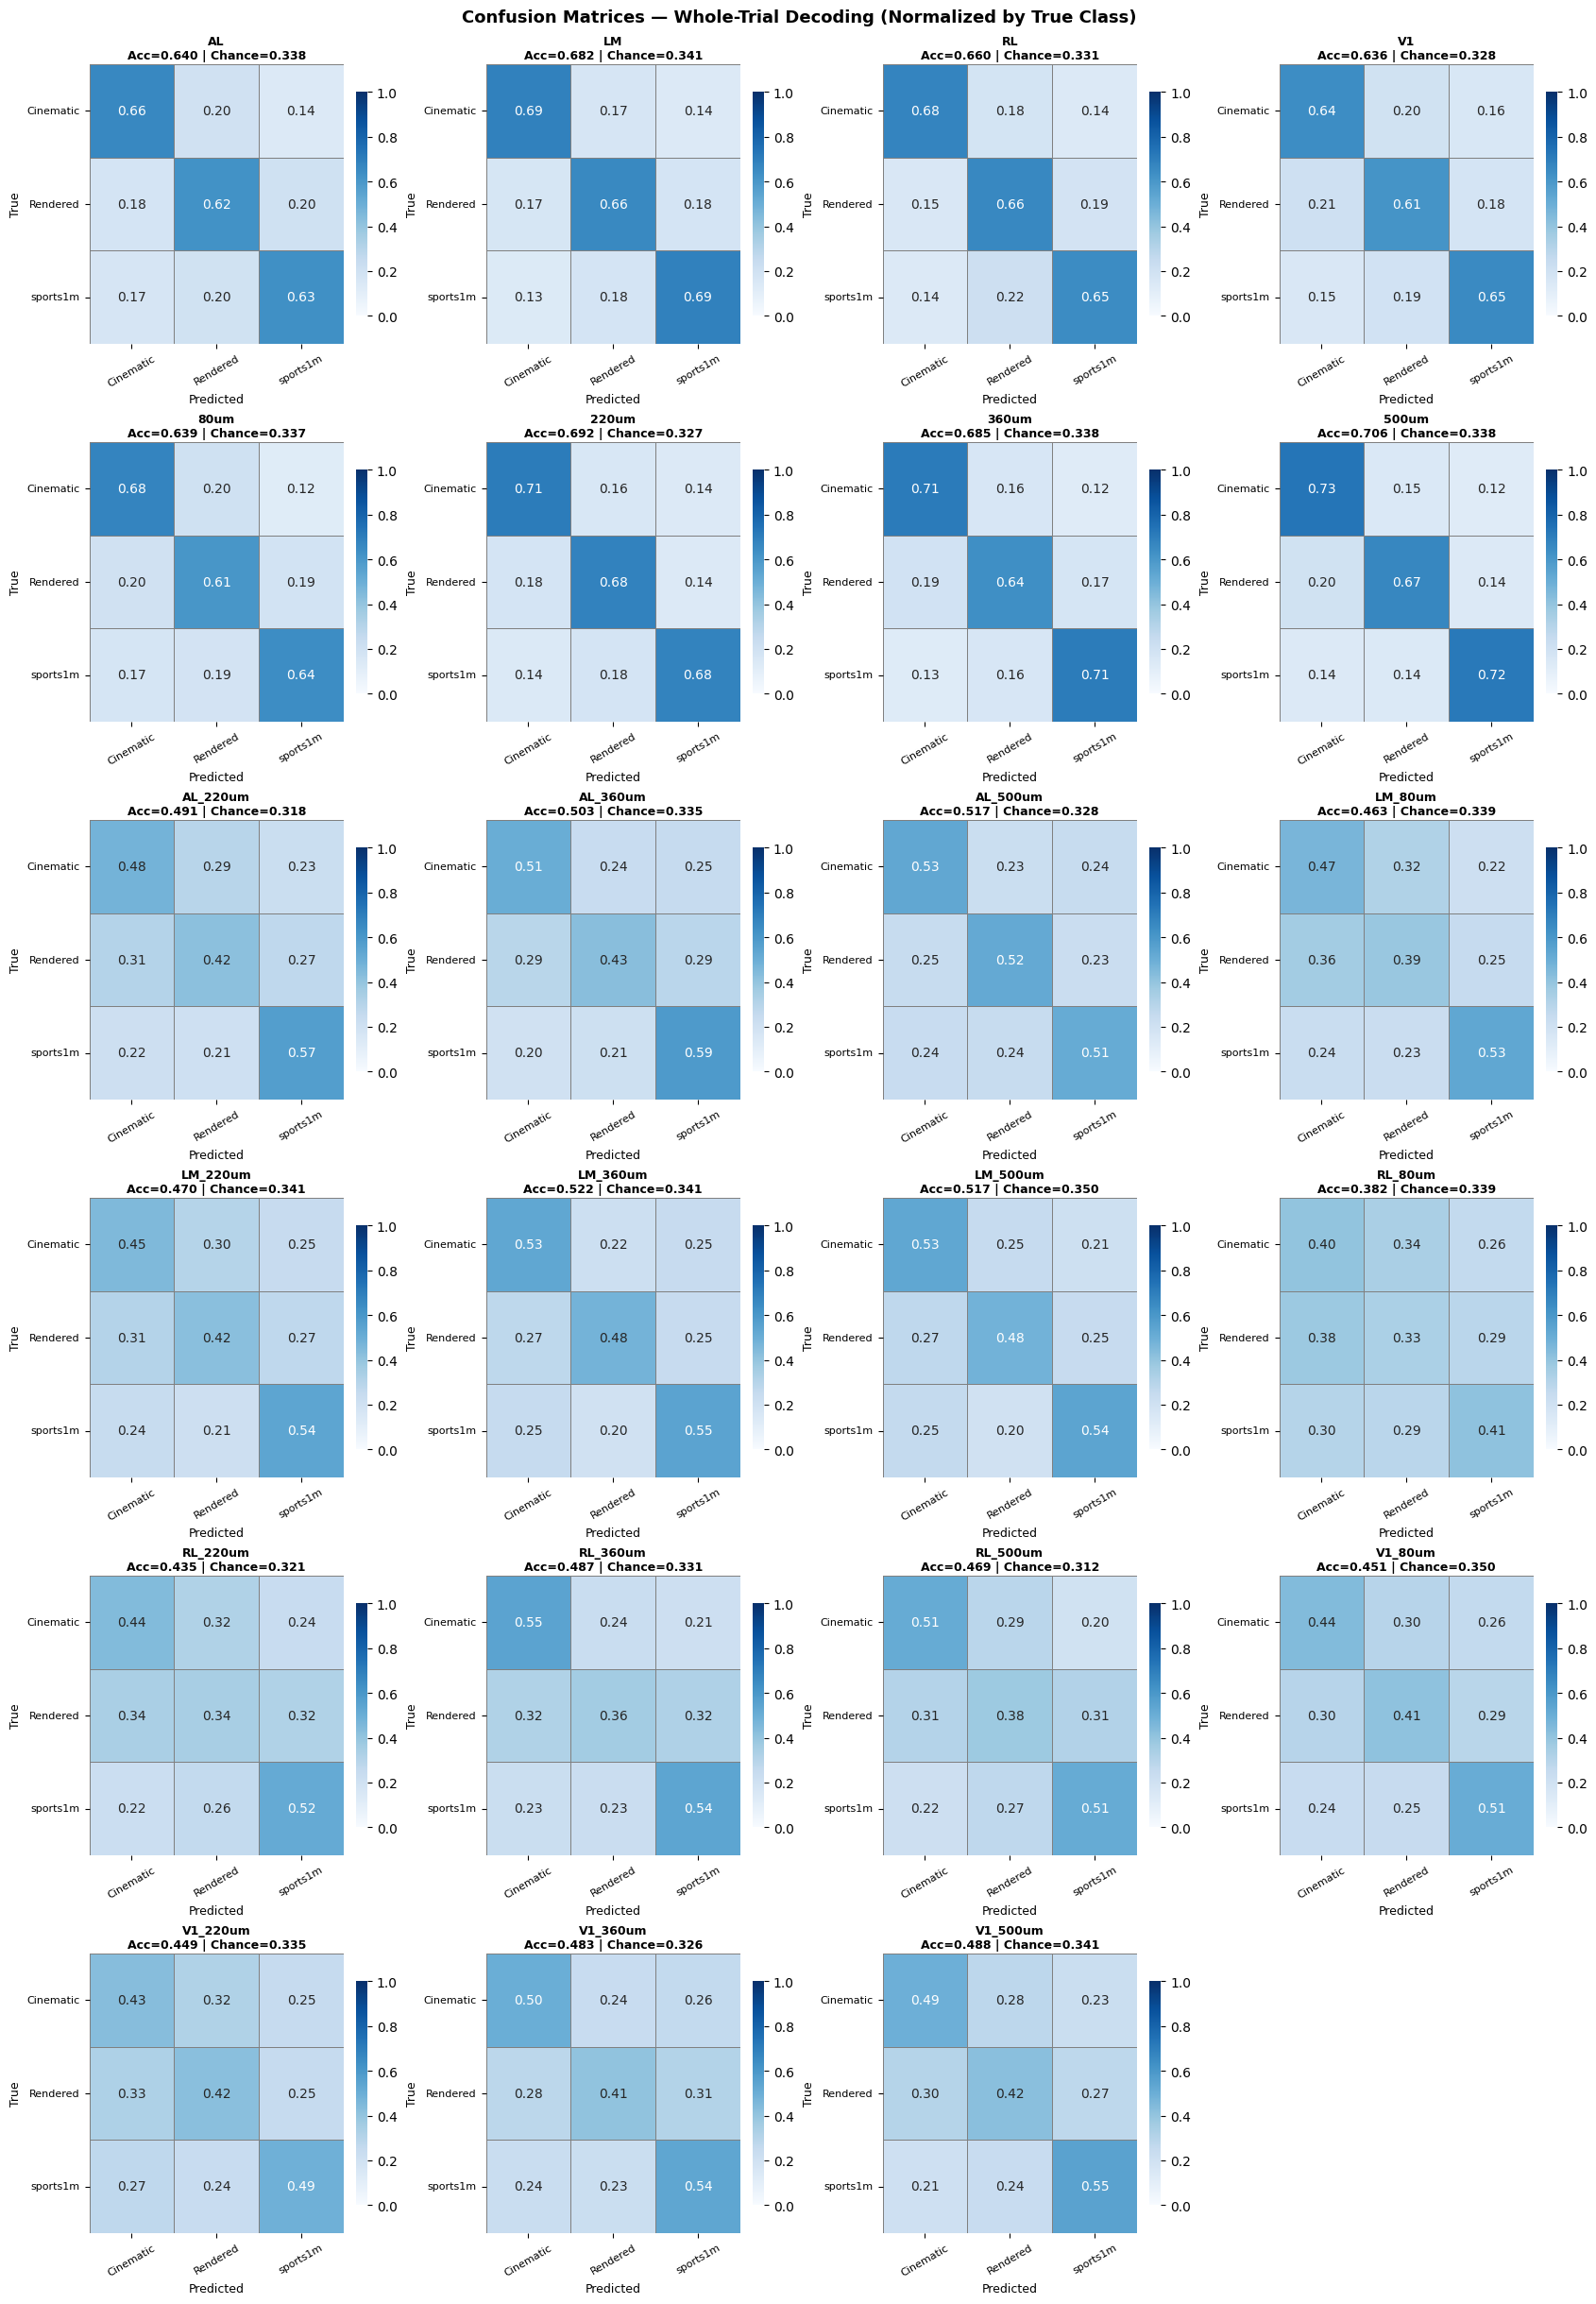

Saved: confusion_matrices.png


In [26]:
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import StratifiedKFold, cross_val_predict
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

# --- FIXED CONFIGURATION ---
MIN_NEURON_FLOOR = 20
N_BOOTSTRAPS = 10
METHOD = 'mean'
WINDOW = None  # Whole trial

# --- Extract features once (whole window, mean) ---
X, y = extract_features(activity, frame_times, trials, window_seconds=WINDOW, method=METHOD)
classes = np.unique(y)
print(f"Feature matrix: {X.shape} | Classes: {classes}")

# --- Calculate subsampling floors ---
counts_area  = merged['brain_area'].value_counts()
counts_depth = merged['depth_bin'].value_counts()
counts_both  = merged.groupby(['brain_area', 'depth_bin']).size()

n_area  = max(counts_area.min(),  MIN_NEURON_FLOOR)
n_depth = max(counts_depth.min(), MIN_NEURON_FLOOR)
n_both  = max(counts_both.min(),  MIN_NEURON_FLOOR)

print(f"Subsampling N-floors -> Area: {n_area} | Depth: {n_depth} | Area x Depth: {n_both}\n")


# ── Storage ──────────────────────────────────────────────────────────────────
results = []
cm_store = {}   # key -> (cm, title_str, acc, chance)

# ── 1. By Brain Area ─────────────────────────────────────────────────────────
print(f"\nDecoding by Brain Area\n")
for area in sorted(merged['brain_area'].dropna().unique()):
    mask = merged['brain_area'].values == area
    if mask.sum() >= n_area:
        acc, std, chance, cm = run_ensemble_decoder_with_cm(X[:, mask], y, n_area, N_BOOTSTRAPS)
        label = f"Area: {area}"
        results.append({'Type': 'Area', 'Group': area, 'Acc': acc, 'Std': std, 'Chance': chance, 'N': mask.sum()})
        cm_store[label] = (cm, f"{area}\nAcc={acc:.3f} | Chance={chance:.3f}")
        print(f"  {area:<20} N={mask.sum():<5} Acc={acc:.3f}±{std:.3f}  Chance={chance:.3f}")
    else:
        print(f"  {area:<20} SKIPPED (N={mask.sum()})")

# ── 2. By Depth ───────────────────────────────────────────────────────────────
print(f"\n\nDecoding by Depth\n")
for depth in sorted(merged['depth_bin'].dropna().unique()):
    mask = merged['depth_bin'].values == depth
    if mask.sum() >= n_depth:
        acc, std, chance, cm = run_ensemble_decoder_with_cm(X[:, mask], y, n_depth, N_BOOTSTRAPS)
        label = f"Depth: {depth}um"
        results.append({'Type': 'Depth', 'Group': f"{depth}um", 'Acc': acc, 'Std': std, 'Chance': chance, 'N': mask.sum()})
        cm_store[label] = (cm, f"{depth}um\nAcc={acc:.3f} | Chance={chance:.3f}")
        print(f"  {str(depth)+'um':<20} N={mask.sum():<5} Acc={acc:.3f}±{std:.3f}  Chance={chance:.3f}")
    else:
        print(f"  {str(depth)+'um':<20} SKIPPED (N={mask.sum()})")

# ── 3. By Area × Depth ────────────────────────────────────────────────────────
print(f"\n\nDecoding by Area × Depth\n")
for area in sorted(merged['brain_area'].dropna().unique()):
    for depth in sorted(merged['depth_bin'].dropna().unique()):
        mask = (merged['brain_area'].values == area) & (merged['depth_bin'].values == depth)
        group_name = f"{area}_{depth}um"
        if mask.sum() >= n_both:
            acc, std, chance, cm = run_ensemble_decoder_with_cm(X[:, mask], y, n_both, N_BOOTSTRAPS)
            label = f"Area×Depth: {group_name}"
            results.append({'Type': 'Area x Depth', 'Group': group_name, 'Acc': acc, 'Std': std, 'Chance': chance, 'N': mask.sum()})
            cm_store[label] = (cm, f"{group_name}\nAcc={acc:.3f} | Chance={chance:.3f}")
            print(f"  {group_name:<25} N={mask.sum():<5} Acc={acc:.3f}±{std:.3f}  Chance={chance:.3f}")
        else:
            print(f"  {group_name:<25} SKIPPED (N={mask.sum()})")

# ── Summary table ─────────────────────────────────────────────────────────────
df_results = (pd.DataFrame(results)
              .sort_values(by='Acc', ascending=False)
              .reset_index(drop=True))
print(df_results.to_string(index=False))

# ── Plot confusion matrices ───────────────────────────────────────────────────
n_cms  = len(cm_store)
n_cols = 4
n_rows = int(np.ceil(n_cms / n_cols))

fig, axes = plt.subplots(n_rows, n_cols,
                         figsize=(n_cols * 4.2, n_rows * 4),
                         constrained_layout=True)
axes = np.array(axes).flatten()

for ax_i, (label, (cm, title)) in enumerate(cm_store.items()):
    plot_confusion_matrix(cm, title, classes, axes[ax_i])

# Hide any unused axes
for ax_i in range(len(cm_store), len(axes)):
    axes[ax_i].set_visible(False)

fig.suptitle('Confusion Matrices — Whole-Trial Decoding (Normalized by True Class)',
             fontsize=13, fontweight='bold', y=1.01)
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: confusion_matrices.png")

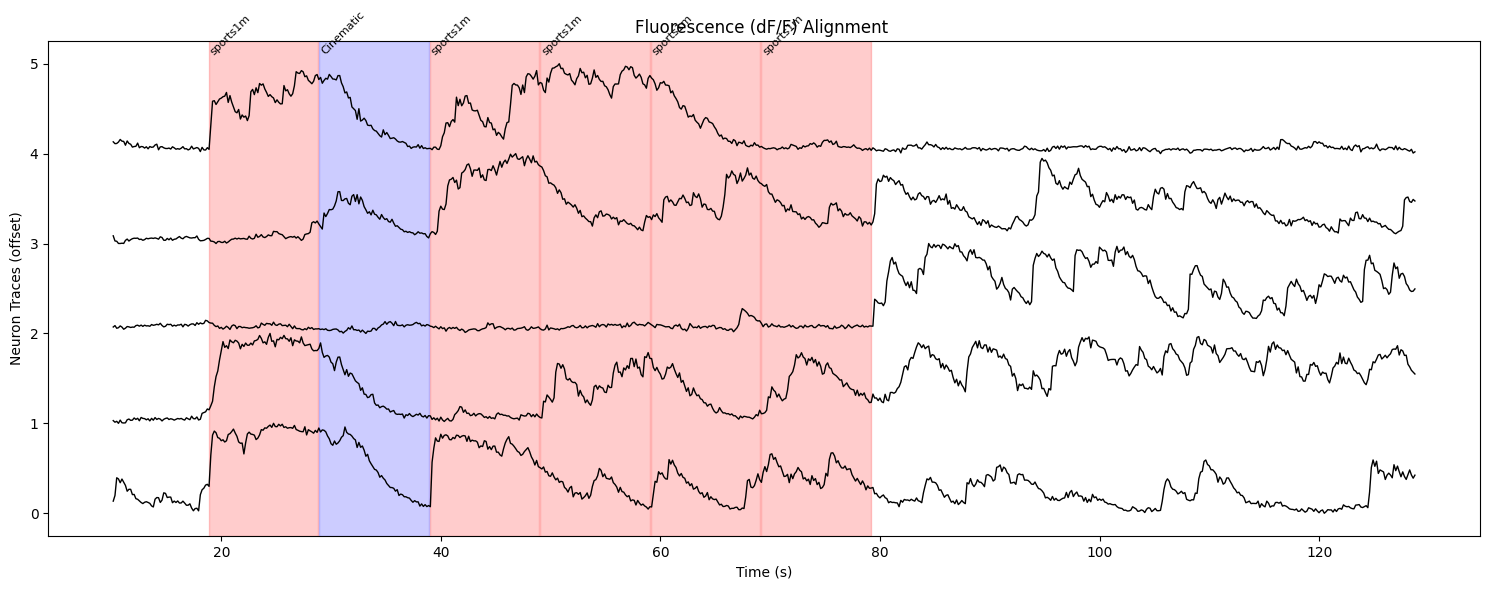

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

def plot_fluorescence_alignment(activity, frame_times, trials, n_neurons=5):
    """Visualizes dF/F traces against trial timings."""
    # Select high-variance neurons for better visualization
    top_idx = np.argsort(activity.var(axis=1))[-n_neurons:]

    # Define a 120s window around the start of the first few trials
    start_time = trials.start_time.min() - 10
    end_time = start_time + 120
    mask = (frame_times >= start_time) & (frame_times <= end_time)

    fig, ax = plt.subplots(figsize=(15, 6))
    colors = {'sports1m': 'red', 'Cinematic': 'blue', 'Rendered': 'green'}

    # Plot traces
    for i, idx in enumerate(top_idx):
        trace = activity[idx, mask]
        # Normalize and offset for visualization
        ax.plot(frame_times[mask], (trace - trace.min()) / (trace.max() - trace.min()) + i, color='black', lw=1)

    # Shade trials
    trials_subset = trials[(trials.start_time >= start_time) & (trials.stop_time <= end_time)]
    for _, trial in trials_subset.iterrows():
        ax.axvspan(trial.start_time, trial.stop_time, color=colors[trial.short_movie_name], alpha=0.2)
        ax.text(trial.start_time, n_neurons + 0.1, trial.short_movie_name, rotation=45, fontsize=8)

    ax.set_title("Fluorescence (dF/F) Alignment ")
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Neuron Traces (offset)")
    plt.tight_layout()
    plt.show()

# Run this once after your load_and_align_data call
plot_fluorescence_alignment(activity, frame_times, trials)